# 09 - Modelado Fase 2

## Objetivo

Este notebook desarrolla la segunda fase de modelado del proyecto.

A partir de los resultados obtenidos en el Notebook 08, se amplía el conjunto de variables, se incorporan modelos más flexibles y se evalúa si enfoques más complejos logran mejorar el desempeño observado en la Fase 1.

El objetivo no es maximizar artificialmente las métricas, sino analizar si la expansión de features y el uso de modelos avanzados permiten capturar señal adicional en los retornos diarios de BTC.

## Alcance

Este notebook incluye:

- Expansión de features.
- Análisis de regímenes de mercado.
- Comparación de modelos.
- Optimización de hiperparámetros.
- Validación temporal.
- Feature importance y SHAP.
- Análisis de robustez.
- Cierre de resultados frente a hipótesis.

Los resultados deben interpretarse como evidencia estadística y no como señales de trading ni recomendaciones de inversión.

# 1. Librerías y configuración

Se importan las librerías necesarias para la expansión de features, el modelado, la evaluación y la interpretación de resultados.

En esta primera etapa se cargan las dependencias básicas. Las librerías específicas para modelos avanzados y SHAP se incorporarán en los bloques correspondientes.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_PATH = r"C:\DS2_BTC_DXY_ORO_VIX"

# 2. Carga del dataset base

Se carga el dataset enriquecido que contiene las variables originales y las features construidas durante la Fase 1.

Este conjunto de datos servirá como base para la expansión de features y el entrenamiento de modelos más flexibles en la Fase 2.

In [3]:
dataset_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "dataset_features_full.csv"
)

features_df = pd.read_csv(
    dataset_path,
    index_col=0,
    parse_dates=True
)

## 2.1. Validación inicial

In [4]:
print("=== VALIDACIÓN INICIAL ===")
print()

print(f"Shape: {features_df.shape}")
print(f"Rango temporal: {features_df.index.min().date()} → {features_df.index.max().date()}")
print(f"Orden cronológico correcto: {features_df.index.is_monotonic_increasing}")
print(f"Duplicados temporales: {features_df.index.duplicated().sum()}")

print()
print("NaN por columna:")
print(features_df.isna().sum())

=== VALIDACIÓN INICIAL ===

Shape: (744, 40)
Rango temporal: 2023-05-17 → 2026-05-05
Orden cronológico correcto: True
Duplicados temporales: 0

NaN por columna:
dxy_Close                 0
dxy_High                  0
dxy_Low                   0
dxy_Open                  0
dxy_Volume                0
dxy_return                0
dxy_volatility_7d         0
dxy_ma_7d                 0
gold_Close                0
gold_High                 0
gold_Low                  0
gold_Open                 0
gold_Volume               0
gold_return               0
gold_volatility_7d        0
gold_ma_7d                0
vix_Close                 0
vix_High                  0
vix_Low                   0
vix_Open                  0
vix_Volume                0
vix_return                0
vix_volatility_7d         0
vix_ma_7d                 0
btc_Close                 0
btc_High                  0
btc_Low                   0
btc_Open                  0
btc_Volume                0
btc_return                0

# 3. Expansión de Features

A partir del conjunto de datos enriquecido se construyen nuevas variables con el objetivo de capturar patrones temporales y relaciones potencialmente no lineales.

Estas variables complementan las features desarrolladas durante la Fase 1 y servirán como insumo para modelos más flexibles.

La construcción de las nuevas variables respeta la causalidad temporal del problema, utilizando únicamente información disponible hasta t−1.

## 3.1. Lags adicionales

Actualmente existe:

- btc_return_lag1
- btc_return_lag2

Se incorpora:

- btc_return_lag3
- btc_return_lag5

In [5]:
features_df["btc_return_lag3"] = (
    features_df["btc_return"]
    .shift(3)
)

features_df["btc_return_lag5"] = (
    features_df["btc_return"]
    .shift(5)
)

## 3.2. Volatilidades múltiples

Actualmente existe:

- btc_volatility_7d

Se incorpora:

- 14 días
- 30 días

In [6]:
features_df["btc_volatility_14d"] = (
    features_df["btc_return"]
    .rolling(14)
    .std()
)

features_df["btc_volatility_30d"] = (
    features_df["btc_return"]
    .rolling(30)
    .std()
)

## 3.3. Medias móviles múltiples

Actualmente existe:

- btc_ma_7d

Se incorpora:

- 14 días
- 30 días

In [7]:
features_df["btc_ma_14d"] = (
    features_df["btc_Close"]
    .rolling(14)
    .mean()
)

features_df["btc_ma_30d"] = (
    features_df["btc_Close"]
    .rolling(30)
    .mean()
)

In [8]:
print ("=== VALIDACIÓN DE LAS FEATURES INCORPORADAS ===")
print ()
print (f"Shape: {features_df.shape}")
print ()
print ("NaN por columnas:")

print(features_df.isna().sum().sort_values(ascending=False).head(15))

=== VALIDACIÓN DE LAS FEATURES INCORPORADAS ===

Shape: (744, 46)

NaN por columnas:
btc_volatility_30d    29
btc_ma_30d            29
btc_volatility_14d    13
btc_ma_14d            13
btc_return_lag5        5
btc_return_lag3        3
dxy_volatility_7d      0
dxy_ma_7d              0
dxy_Close              0
dxy_High               0
dxy_Low                0
dxy_Open               0
dxy_Volume             0
dxy_return             0
gold_return            0
dtype: int64


## 3.4. Interacciones entre variables

Además de las variables individuales, se construyen algunas interacciones simples entre factores relevantes.

Estas variables buscan capturar posibles efectos conjuntos entre la volatilidad de BTC y las condiciones de mercado representadas por VIX y DXY.

### 3.4.1. VIX × Volatilidad BTC

In [9]:
features_df["vix_x_btc_volatility"] = (
    features_df["vix_Close"]
    *
    features_df["btc_volatility_7d"]
)

### 3.4.2. DXY × Volatilidad BTC

In [10]:
features_df["dxy_x_btc_volatility"] = (
    features_df["dxy_return"]
    *
    features_df["btc_volatility_7d"]
)

### 3.4.3. Gold × Volatilidad BTC

In [11]:
features_df["gold_x_btc_volatility"] = (
    features_df["gold_return"]
    *
    features_df["btc_volatility_7d"]
)

### 3.4.4. Validación

In [12]:
print("=== VALIDACIÓN DE INTERACCIONES ===")
print()

print(f"Shape: {features_df.shape}")

print()
print(
    features_df[
        [
            "vix_x_btc_volatility",
            "dxy_x_btc_volatility",
            "gold_x_btc_volatility"
        ]
    ].head()
)

=== VALIDACIÓN DE INTERACCIONES ===

Shape: (744, 49)

            vix_x_btc_volatility  dxy_x_btc_volatility  gold_x_btc_volatility
Date                                                                         
2023-05-17              0.205141              0.000038              -0.000047
2023-05-18              0.186821              0.000079              -0.000142
2023-05-19              0.190194             -0.000042               0.000128
2023-05-22              0.211703              0.000000              -0.000024
2023-05-23              0.248897              0.000038              -0.000016


## 3.5 Regímenes de mercado

Se incorpora una variable categórica sencilla para representar diferentes estados del mercado.

La hipótesis subyacente es que la dinámica de BTC puede variar entre períodos de baja y alta volatilidad, por lo que identificar estos contextos podría aportar información adicional a los modelos.

### 3.5.1. Primer enfoque

Tomar la mediana de la volatilidad de BTC.

In [13]:
split_index = int(len(features_df) * 0.70)

In [14]:
vol_threshold = (
    features_df["btc_volatility_7d"]
    .iloc[:split_index]
    .median()
)

print(vol_threshold)

0.0216944604217266


### 3.5.2. Construcción del régimen

In [15]:
features_df["high_vol_regime"] = (
    features_df["btc_volatility_7d"]
    >
    vol_threshold
).astype(int)

### 3.5.3. Validación

Interpretación:

- Baja volatilidad --> 0
- Alta volatilidad --> 1

In [16]:
print(
    features_df["high_vol_regime"]
    .value_counts()
)

high_vol_regime
0    409
1    335
Name: count, dtype: int64


## 3.6. Validación de las features expandidas

Se verifica el impacto de las nuevas variables sobre el conjunto de datos, identificando los valores faltantes introducidos por las operaciones temporales.

Posteriormente se eliminarán las observaciones incompletas para construir el dataset definitivo de modelado de la Fase 2.

In [17]:
print("=== DATASET EXPANDIDO ===")
print()

print(f"Shape actual: {features_df.shape}")

print()
print("Top 15 columnas con NaN:")

print(
    features_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

=== DATASET EXPANDIDO ===

Shape actual: (744, 50)

Top 15 columnas con NaN:
btc_ma_30d            29
btc_volatility_30d    29
btc_ma_14d            13
btc_volatility_14d    13
btc_return_lag5        5
btc_return_lag3        3
dxy_Low                0
dxy_Open               0
gold_Close             0
gold_High              0
gold_Low               0
gold_Open              0
dxy_Volume             0
dxy_return             0
dxy_volatility_7d      0
dtype: int64


## 3.7. Construcción del dataset de modelado de Fase 2

Una vez generadas las nuevas variables, se eliminan las observaciones incompletas producidas por las operaciones temporales.

El objetivo es obtener un conjunto de datos consistente para el entrenamiento y evaluación de los modelos de la Fase 2.

In [18]:
phase2_df = features_df.dropna()

print("=== DATASET FASE 2 ===")
print()

print(f"Shape original: {features_df.shape}")
print(f"Shape final: {phase2_df.shape}")

print()
print(f"Filas eliminadas: {len(features_df) - len(phase2_df)}")

print()
print("NaN restantes:")
print(phase2_df.isna().sum().sum())

=== DATASET FASE 2 ===

Shape original: (744, 50)
Shape final: (715, 50)

Filas eliminadas: 29

NaN restantes:
0


## 3.8. Exportación del dataset de Fase 2

Una vez finalizada la expansión de variables y eliminadas las observaciones incompletas, se exporta el dataset definitivo utilizado durante la etapa de modelado avanzado.

Este conjunto de datos constituye la entrada de los modelos de la Fase 2 y permite reproducir los resultados sin necesidad de reconstruir nuevamente las variables.

In [19]:
phase2_df.to_csv(
    os.path.join(
        PROJECT_PATH,
        "data",
        "processed",
        "dataset_phase2.csv"
    )
)

print("Dataset de Fase 2 exportado correctamente.")

Dataset de Fase 2 exportado correctamente.


## 3.9. Cierre del bloque de ingeniería de atributos de Fase 2

Durante esta etapa se expandió el conjunto original de variables mediante la construcción de nuevas features orientadas a capturar patrones temporales, condiciones de volatilidad e interacciones entre activos.

Se incorporaron lags adicionales de BTC, nuevas ventanas de volatilidad y medias móviles, variables de interacción entre volatilidad de BTC y factores macro-financieros, y una variable binaria de régimen de volatilidad.

Luego de la expansión, se eliminaron las observaciones incompletas generadas por las operaciones temporales, obteniendo un dataset final consistente para la etapa de modelado de Fase 2.

Este bloque deja preparado el conjunto de datos que será utilizado para comparar modelos más flexibles y evaluar si la información adicional permite mejorar los resultados obtenidos en la Fase 1.

El dataset expandido pasó de 744 observaciones y 40 variables iniciales a 715 observaciones y 50 variables luego de la ingeniería de atributos. Tras eliminar los valores faltantes generados por ventanas móviles y lags extendidos, el dataset final de Fase 2 quedó listo para modelado, sin valores nulos restantes.

# 4. Definición de variables y partición temporal

Se define nuevamente la matriz de variables explicativas y la variable objetivo utilizando el conjunto de datos expandido de la Fase 2.

La partición entrenamiento-prueba mantiene el orden temporal de las observaciones para evitar leakage y preservar la naturaleza secuencial del problema.

## 4.1. Definición de variables

In [20]:
X_phase2 = phase2_df.drop(
    columns=["target_btc_return_t1"]
)

y_phase2 = phase2_df["target_btc_return_t1"]

## 4.2. Partición temporal

In [21]:
split_index = int(len(X_phase2) * 0.7)

print(f"Punto de corte: {split_index}")

Punto de corte: 500


In [22]:
X_train = X_phase2.iloc[:split_index]
X_test = X_phase2.iloc[split_index:]

y_train = y_phase2.iloc[:split_index]
y_test = y_phase2.iloc[split_index:]

## 4.3. Validación

In [23]:
print("=== SHAPES ===")
print()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print()

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

=== SHAPES ===

X_train: (500, 49)
X_test : (215, 49)

y_train: (500,)
y_test : (215,)


# 5. Comparación de modelos

Una vez finalizada la expansión de features, se entrenan distintos modelos con el objetivo de evaluar si la información adicional incorporada durante la Fase 2 permite mejorar los resultados obtenidos en la Fase 1.

Se comparan tres enfoques:

- Regresión Lineal.
- Random Forest.
- XGBoost.

La regresión lineal funciona como referencia interpretable, mientras que Random Forest y XGBoost permiten capturar relaciones no lineales y posibles interacciones complejas entre variables.

Todos los modelos se entrenan y evalúan utilizando la misma partición temporal train-test para garantizar una comparación consistente.

## 5.1 Librerías de modelado

Se importan los modelos y métricas necesarios para la comparación inicial.

En esta etapa se utilizan configuraciones base, dejando la optimización de hiperparámetros para el bloque posterior.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## 5.2 Función de evaluación

Se define una función auxiliar para calcular las métricas de evaluación de manera uniforme en todos los modelos.

Esto permite reducir repetición de código y asegurar que todos los modelos sean evaluados bajo el mismo criterio.

In [25]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "Modelo": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 5.3 Regresión Lineal

Se entrena nuevamente una regresión lineal utilizando el conjunto expandido de variables de la Fase 2.

El objetivo es evaluar si la incorporación de nuevas features temporales, interacciones y regímenes de mercado permite mejorar el desempeño obtenido en la Fase 1.

### 5.3.1. Entrenamiento del modelo

In [26]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 0., 0., 0.,..., 0.,-0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](49,)","['dxy_Close','dxy_High','dxy_Low',...,'dxy_x_btc_volatility', 'gold_x_btc_volatility','high_vol_regime']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.004827
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


### 5.3.2. Predicciones del modelo

In [27]:
linear_pred = linear_model.predict(
    X_test
)

### 5.3.3. Evaluación del modelo

In [28]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

print(linear_results)

{'Modelo': 'Linear Regression', 'MAE': 0.018771972848532572, 'RMSE': np.float64(0.02590745755053428), 'R2': -0.006272818686340775}


### 5.3.4. Conclusiones

La expansión de variables de la Fase 2 no produjo mejoras sustanciales en el desempeño de la regresión lineal respecto de la Fase 1.

| Modelo              |      MAE |     RMSE |        R² |
| ------------------- | -------: | -------: | --------: |
| Media histórica F1  | 0.018624 | 0.025780 | -0.016449 |
| Regresión Lineal F1 | 0.018409 | 0.025659 | -0.006929 |
| Regresión Lineal F2 | 0.018772 | 0.025907 | -0.006273 |

Esto sugiere que la información adicional incorporada podría no manifestarse mediante relaciones estrictamente lineales, justificando la exploración de modelos más flexibles capaces de capturar comportamientos no lineales y efectos complejos entre variables.

## 5.4 Random Forest

Se entrena un modelo Random Forest para evaluar si la información adicional incorporada durante la Fase 2 puede ser aprovechada mediante relaciones no lineales.

A diferencia de la regresión lineal, este modelo puede capturar interacciones complejas entre variables y asignar distinta importancia a cada feature sin asumir relaciones estrictamente lineales.

### 5.4.1. Creación del modelo

In [29]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### 5.4.2. Entrenamiento del modelo

In [30]:
rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### 5.4.3. Predicciones del modelo

In [31]:
rf_pred = rf_model.predict(
    X_test
)

### 5.4.4. Evaluación del modelo

In [32]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

print(rf_results)

{'Modelo': 'Random Forest', 'MAE': 0.01968722830889222, 'RMSE': np.float64(0.026785814979354172), 'R2': -0.07566213387506227}


### 5.4.5. Conclusiones

Los resultados obtenidos por Random Forest muestran un deterioro respecto de los modelos lineales.

| Modelo              |          MAE |         RMSE |            R² |
| ------------------- | -----------: | -----------: | ------------: |
| Media histórica F1  |     0.018624 |     0.025780 |     -0.016449 |
| Regresión Lineal F1 | **0.018409** | **0.025659** |     -0.006929 |
| Regresión Lineal F2 |     0.018772 |     0.025907 | **-0.006273** |
| Random Forest F2    |     0.019589 |     0.026617 |     -0.062179 |


Esto sugiere que las relaciones no lineales capturadas por el bosque no logran generalizar adecuadamente sobre el conjunto de prueba, posiblemente debido a la alta proporción de ruido característica de los retornos diarios de BTC.

La mayor complejidad del modelo no se traduce necesariamente en una mejora del desempeño predictivo.

## 5.5 XGBoost

Se entrena un modelo XGBoost para evaluar si una estrategia de boosting es capaz de capturar relaciones más complejas entre las variables y mejorar el desempeño obtenido por los modelos anteriores.

A diferencia de Random Forest, XGBoost construye los árboles de manera secuencial, corrigiendo progresivamente los errores cometidos por los árboles anteriores.

### 5.5.1. Creación del modelo

In [33]:
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)

### 5.5.2. Entrenamiento del modelo

In [34]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 5.5.3. Predicciones del modelo

In [35]:
xgb_pred = xgb_model.predict(
    X_test
)

### 5.5.4. Evaluación del modelo

In [36]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

print(xgb_results)

{'Modelo': 'XGBoost', 'MAE': 0.02089240367391682, 'RMSE': np.float64(0.028462544688457006), 'R2': -0.21454497714680265}


### 5.5.5. Conclusiones

XGBoost fue incorporado con el objetivo de evaluar si una estrategia de boosting era capaz de capturar relaciones más complejas entre las variables y mejorar los resultados obtenidos por los modelos anteriores.

Sin embargo, el desempeño observado sobre el conjunto de prueba fue inferior tanto a la Regresión Lineal como a Random Forest, evidenciando una pérdida significativa de capacidad de generalización.

Nuevamente, estos resultados sugieren que la mayor complejidad del modelo no se tradujo en una mejora predictiva. Por el contrario, la flexibilidad adicional de XGBoost podría haber favorecido el aprendizaje de patrones específicos del conjunto de entrenamiento que no lograron reproducirse en observaciones futuras.

En consecuencia, para el horizonte temporal y el conjunto de variables utilizados en este proyecto, no se encontraron evidencias de que un modelo de boosting aportara ventajas respecto de enfoques más simples.

Este resultado no invalida la utilidad de XGBoost en otros contextos, sino que refuerza la importancia de evaluar empíricamente cada modelo y evitar asumir que una mayor sofisticación implica necesariamente un mejor desempeño.

## 5.6. Conclusiones del bloque

Se compararon tres enfoques de complejidad creciente utilizando el conjunto de variables expandido de la Fase 2.

| Modelo              |          MAE |         RMSE |            R² |
| ------------------- | -----------: | -----------: | ------------: |
| Media histórica F1  |     0.018624 |     0.025780 |     -0.016449 |
| Regresión Lineal F1 | **0.018409** | **0.025659** |     -0.006929 |
| Regresión Lineal F2 |     0.018772 |     0.025907 | **-0.006273** |
| Random Forest F2    |     0.019589 |     0.026617 |     -0.062179 |
| XGBoost F2          |     0.020892 |     0.028462 |     -0.214545 |


La Regresión Lineal presentó el mejor desempeño global, obteniendo resultados similares a los observados en la Fase 1. La incorporación de nuevas variables no produjo mejoras sustanciales bajo una hipótesis lineal.

Por su parte, Random Forest y XGBoost mostraron un deterioro progresivo en las métricas de evaluación, sugiriendo una menor capacidad de generalización sobre el conjunto de prueba. La mayor complejidad de estos modelos no se tradujo en un mejor desempeño predictivo.

Estos resultados indican que la señal contenida en los retornos diarios de BTC podría ser débil y que una mayor flexibilidad del modelo no garantiza necesariamente una mejora en la capacidad de predicción.

Asimismo, los resultados obtenidos abren nuevas líneas de exploración, como la ampliación del horizonte temporal, la incorporación de nuevas variables o el análisis en otras frecuencias temporales.

# 6. Optimización de hiperparámetros

Con el objetivo de evaluar el máximo potencial de los modelos no lineales, se realiza una búsqueda de hiperparámetros mediante RandomizedSearchCV.

La optimización permite explorar distintas configuraciones y determinar si las diferencias observadas anteriormente se debían a una elección subóptima de parámetros o a limitaciones inherentes a la señal contenida en los datos.

## Validación temporal interna

Para la optimización de hiperparámetros se utiliza `TimeSeriesSplit`, una estrategia de validación cruzada diseñada para respetar el orden temporal de las observaciones.

A diferencia de la validación cruzada clásica, este enfoque evita entrenar modelos con información futura para evaluar períodos pasados.

De este modo, la búsqueda de hiperparámetros mantiene la misma lógica temporal aplicada durante todo el proyecto.

## 6.1. Librerías para optimización

Se importan las herramientas necesarias para realizar la búsqueda aleatoria de hiperparámetros.

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

In [38]:
tscv = TimeSeriesSplit(
    n_splits=3
)

tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)

## 6.2. Optimización de Random Forest

Se optimizan los hiperparámetros de Random Forest mediante `RandomizedSearchCV`.

La búsqueda utiliza `TimeSeriesSplit` como estrategia de validación interna, preservando el orden temporal de las observaciones y evitando que información futura intervenga en la evaluación de configuraciones pasadas.

El objetivo es determinar si una configuración más adecuada permite mejorar el desempeño observado por Random Forest en su versión base.

### 6.2.1. Definición del espacio de búsqueda

In [39]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

### 6.2.2. Entrenamiento del modelo

In [40]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

In [41]:
rf_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on thi

### 6.2.3. Mejor configuración encontrada

In [42]:
print("=== RANDOM FOREST OPTIMIZADO ===")
print()

print("Mejores hiperparámetros:")
print(rf_search.best_params_)

print()
print("Mejor score interno:")
print(rf_search.best_score_)

=== RANDOM FOREST OPTIMIZADO ===

Mejores hiperparámetros:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3}

Mejor score interno:
-0.024166024620148514


### 6.2.4. Evaluación sobre test

In [43]:
rf_optimized_model = rf_search.best_estimator_

rf_optimized_pred = rf_optimized_model.predict(
    X_test
)

rf_optimized_results = evaluate_model(
    "Random Forest Optimizado",
    y_test,
    rf_optimized_pred
)

print(rf_optimized_results)

{'Modelo': 'Random Forest Optimizado', 'MAE': 0.019001481803342306, 'RMSE': np.float64(0.026291821176056628), 'R2': -0.036352479491144285}


### 6.2.5. Conclusiones

La optimización de hiperparámetros permitió mejorar el desempeño observado en la versión base de Random Forest, evidenciando que parte del deterioro inicial se debía a una configuración subóptima.

| Modelo                   |          MAE |         RMSE |            R² |
| ------------------------ | -----------: | -----------: | ------------: |
| Media histórica F1       |     0.018624 |     0.025780 |     -0.016449 |
| Regresión Lineal F1      | **0.018409** | **0.025659** |     -0.006929 |
| Regresión Lineal F2      | **0.018772** | **0.025907** | **-0.006273** |
| Random Forest            |     0.019589 |     0.026617 |     -0.062179 |
| XGBoost                  |     0.020892 |     0.028462 |     -0.214545 |
| Random Forest Optimizado |     0.019001 |     0.026292 |     -0.036352 |


Sin embargo, las mejoras obtenidas no fueron suficientes para superar los resultados alcanzados por la Regresión Lineal.

Estos resultados sugieren que, para el conjunto de datos y horizonte temporal considerados, la mayor complejidad y flexibilidad de Random Forest no se traducen en una mejora significativa de la capacidad predictiva.

## 6.3. Optimización de XGBoost

Luego de observar un desempeño inferior al esperado en la configuración base, se realiza una optimización de hiperparámetros sobre XGBoost con el objetivo de evaluar su máximo potencial dentro del conjunto de datos disponible.

Al igual que en Random Forest, la búsqueda se lleva a cabo mediante RandomizedSearchCV utilizando TimeSeriesSplit como estrategia de validación interna, preservando el orden temporal de las observaciones y evitando introducir información futura durante el proceso de selección.

El propósito de esta etapa es determinar si los resultados obtenidos previamente se debían a una configuración subóptima del modelo o si, por el contrario, las limitaciones observadas responden a la naturaleza de la señal contenida en los datos.

### 6.3.1. Definición del espacio de búsqueda

In [44]:
xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

### 6.3.2. Entrenamiento del modelo

In [45]:
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

In [46]:
xgb_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly

### 6.3.3. Mejor configuración encontrada

In [47]:
print("=== XGBOOST OPTIMIZADO ===")
print()

print("Mejores hiperparámetros:")
print(xgb_search.best_params_)

print()
print("Mejor score interno:")
print(xgb_search.best_score_)

=== XGBOOST OPTIMIZADO ===

Mejores hiperparámetros:
{'subsample': 0.8, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Mejor score interno:
-0.022752988619854028


### 6.3.4. Evaluación sobre test

In [48]:
xgb_optimized_model = xgb_search.best_estimator_

xgb_optimized_pred = xgb_optimized_model.predict(
    X_test
)

xgb_optimized_results = evaluate_model(
    "XGBoost Optimizado",
    y_test,
    xgb_optimized_pred
)

print(xgb_optimized_results)

{'Modelo': 'XGBoost Optimizado', 'MAE': 0.018778603118274808, 'RMSE': np.float64(0.02597676202802214), 'R2': -0.011663736780042955}


### 6.3.5. Conclusiones

La optimización de hiperparámetros permitió mejorar significativamente el desempeño de XGBoost respecto de su configuración base, evidenciando que parte del deterioro inicial se debía a una parametrización inadecuada.

| Modelo                   |          MAE |         RMSE |            R² |
| ------------------------ | -----------: | -----------: | ------------: |
| Media histórica F1       |     0.018624 |     0.025780 |     -0.016449 |
| Regresión Lineal F1      | **0.018409** | **0.025659** |     -0.006929 |
| Regresión Lineal F2      |     0.018772 | **0.025907** | **-0.006273** |
| Random Forest F2         |     0.019589 |     0.026617 |     -0.062179 |
| XGBoost F2               |     0.020892 |     0.028462 |     -0.214545 |
| Random Forest Optimizado |     0.019001 |     0.026292 |     -0.036352 |
| XGBoost Optimizado       |     0.018779 |     0.025977 |     -0.011664 |


Sin embargo, aun en su versión optimizada, XGBoost no logró superar los resultados obtenidos por las regresiones lineales.

Estos resultados sugieren que, para el horizonte temporal y las variables consideradas, la mayor capacidad de representación del modelo no se traduce en una mejora efectiva de la capacidad predictiva.

La complejidad adicional permitió recuperar parte del desempeño perdido, pero no aportó una ventaja suficiente respecto de enfoques más simples e interpretables.

## 6.4. Comparación global de modelos

Se consolidan los resultados obtenidos en todas las etapas del proyecto con el objetivo de comparar el desempeño de los distintos enfoques evaluados.

La comparación incluye los modelos baseline, las regresiones lineales y las versiones base y optimizadas de Random Forest y XGBoost.

### 6.4.1. Tabla comparativa

In [49]:
historical_results = {
    "Modelo": "Baseline Media Histórica Fase 1",
    "MAE": 0.018624,
    "RMSE": 0.025780,
    "R2": -0.016449
}

linear_phase1_results = {
    "Modelo": "Regresión Lineal Fase 1",
    "MAE": 0.018409,
    "RMSE": 0.025659,
    "R2": -0.006929
}

In [50]:
comparison_final_df = pd.DataFrame([
    historical_results,
    linear_phase1_results,
    linear_results,
    rf_results,
    xgb_results,
    rf_optimized_results,
    xgb_optimized_results
])

comparison_final_df = comparison_final_df.round(6)

comparison_final_df

,Modelo,MAE,RMSE,R2
0,Baseline Media Histórica Fase 1,0.018624,0.025780,-0.016449
1,Regresión Lineal Fase 1,0.018409,0.025659,-0.006929
2,Linear Regression,0.018772,0.025907,-0.006273
3,Random Forest,0.019687,0.026786,-0.075662
4,XGBoost,0.020892,0.028463,-0.214545
5,Random Forest Optimizado,0.019001,0.026292,-0.036352
6,XGBoost Optimizado,0.018779,0.025977,-0.011664


### 6.4.2 Exportación de resultados

Se exporta una tabla consolidada con las métricas obtenidas por todos los modelos evaluados durante el proyecto.

Esta tabla resume el desempeño relativo de cada enfoque y permite reproducir las comparaciones realizadas sin necesidad de ejecutar nuevamente los entrenamientos.

In [51]:
comparison_final_df.to_csv(
    os.path.join(
        PROJECT_PATH,
        "data",
        "processed",
        "model_comparison_final.csv"
    ),
    index=False
)

print("Tabla comparativa exportada correctamente.")

Tabla comparativa exportada correctamente.


### 6.4.3. Conclusiones

La optimización de hiperparámetros permitió mejorar el desempeño de Random Forest y XGBoost respecto de sus configuraciones base, evidenciando que parte del deterioro inicial se debía a configuraciones subóptimas.

Sin embargo, aun en sus versiones optimizadas, los modelos más complejos no lograron superar de manera consistente los resultados obtenidos por las regresiones lineales.

La Regresión Lineal de Fase 2 presentó el mejor R² del conjunto, mientras que la Regresión Lineal de Fase 1 obtuvo los menores errores absolutos y cuadráticos.

Estos resultados sugieren que, para el horizonte temporal y el conjunto de variables considerados, la complejidad adicional de los modelos no se traduce necesariamente en una mejora de la capacidad predictiva.

En consecuencia, las regresiones lineales continúan representando la alternativa más robusta e interpretable dentro del alcance de este proyecto.

# 7. Explicabilidad e importancia de variables

Luego de comparar los modelos y evaluar sus versiones optimizadas, se analiza la importancia de las variables utilizadas durante la Fase 2.

El objetivo de este bloque es interpretar qué features tuvieron mayor peso dentro de los modelos complejos, especialmente en XGBoost optimizado, y evaluar si dichas variables presentan coherencia con el razonamiento financiero desarrollado durante el proyecto.

Este análisis no busca demostrar causalidad, sino aportar interpretabilidad sobre el comportamiento interno de los modelos.

## 7.1. Feature importance de XGBoost

Se analiza la importancia de variables del modelo XGBoost optimizado.

Esta técnica permite observar qué features fueron utilizadas con mayor frecuencia o peso relativo durante la construcción de los árboles del modelo.

In [52]:
xgb_importance_df = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": xgb_optimized_model.feature_importances_
    }
)

xgb_importance_df = (
    xgb_importance_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

xgb_importance_df.head(15)

,Feature,Importance
0,gold_Close,0.044258
1,gold_Volume,0.039795
2,gold_return_lag1,0.036895
3,vix_Open,0.036342
4,vix_Close,0.034945
5,dxy_Close,0.034934
6,gold_ma_7d,0.033785
7,vix_return,0.033115
8,btc_High,0.032825
9,btc_volatility_7d_lag1,0.031826


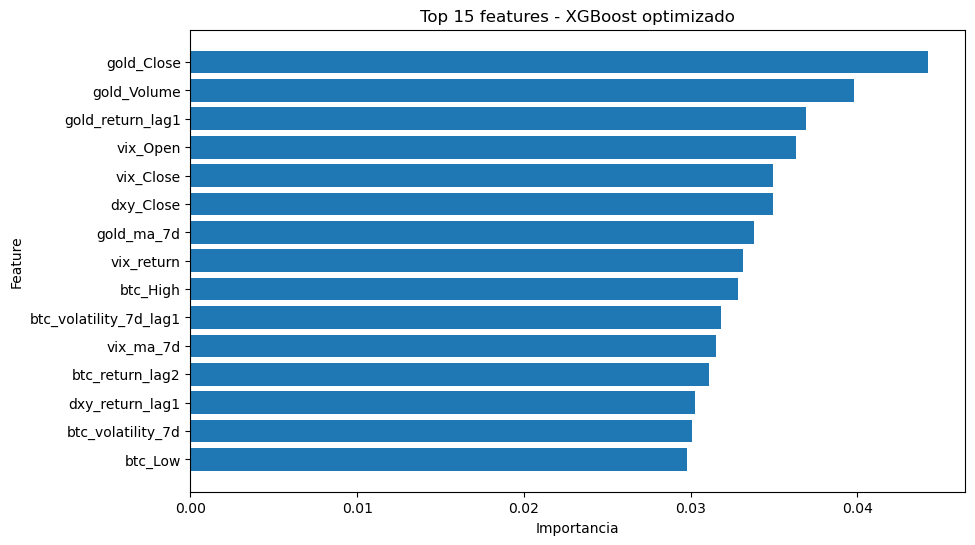

In [53]:
top_features = xgb_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 15 features - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.show()

### 7.1.1. Conclusiones

El análisis de importancia de variables de XGBoost optimizado permitió obtener una primera aproximación sobre las features que el modelo consideró más relevantes durante el proceso de entrenamiento.

Los resultados muestran una presencia destacada de variables asociadas al oro, al VIX y al índice DXY, lo que sugiere que la información proveniente de otros activos financieros podría aportar señal adicional para explicar el comportamiento futuro de BTC.

Sin embargo, la importancia obtenida mediante `feature_importances_` debe interpretarse con cautela, ya que refleja únicamente la utilidad relativa de las variables dentro de la estructura de árboles del modelo y no implica relaciones causales ni permite determinar la dirección del efecto sobre las predicciones.

Asimismo, dado que el desempeño predictivo global del modelo continuó siendo inferior al de las regresiones lineales, las importancias observadas podrían estar reflejando tanto relaciones genuinas como patrones específicos del conjunto de entrenamiento.

Por este motivo, se incorpora un análisis adicional mediante SHAP con el objetivo de profundizar la interpretabilidad del modelo y comprender de manera más detallada la contribución individual de cada variable sobre las predicciones.

## 7.2 Explicabilidad con SHAP

Con el objetivo de profundizar la interpretabilidad del modelo, se aplica la librería SHAP (SHapley Additive exPlanations) sobre XGBoost optimizado.

A diferencia de las medidas tradicionales de importancia de variables, SHAP permite cuantificar la contribución individual de cada feature sobre las predicciones realizadas por el modelo.

Este análisis aporta una visión más detallada del comportamiento interno del algoritmo y facilita la interpretación de los factores que influyen en la predicción del retorno futuro de BTC.

### 7.2.1 Librerías

Se importan las herramientas necesarias para generar explicaciones locales y globales mediante SHAP.

In [54]:
import shap

C:\Users\amilc\anaconda3\envs\proyecto_ds2_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 7.2.2 Construcción del explicador

Se construye un objeto SHAP asociado al modelo XGBoost optimizado, permitiendo analizar la contribución de cada variable a las predicciones realizadas.

In [55]:
explainer = shap.TreeExplainer(
    xgb_optimized_model
)

### 7.2.3 Cálculo de valores SHAP

Se calculan los valores SHAP sobre el conjunto de prueba con el objetivo de interpretar el comportamiento del modelo sobre observaciones no utilizadas durante el entrenamiento.

In [56]:
shap_values = explainer.shap_values(
    X_test
)

### 7.2.4 Summary Plot

Se genera un gráfico resumen de SHAP con el objetivo de visualizar la contribución de cada variable sobre las predicciones del modelo.

El gráfico permite analizar simultáneamente:

- la importancia relativa de cada feature;
- la dirección de su influencia sobre las predicciones;
- la distribución de sus efectos a lo largo del conjunto de prueba.

Este análisis proporciona una visión global del comportamiento interno de XGBoost optimizado.

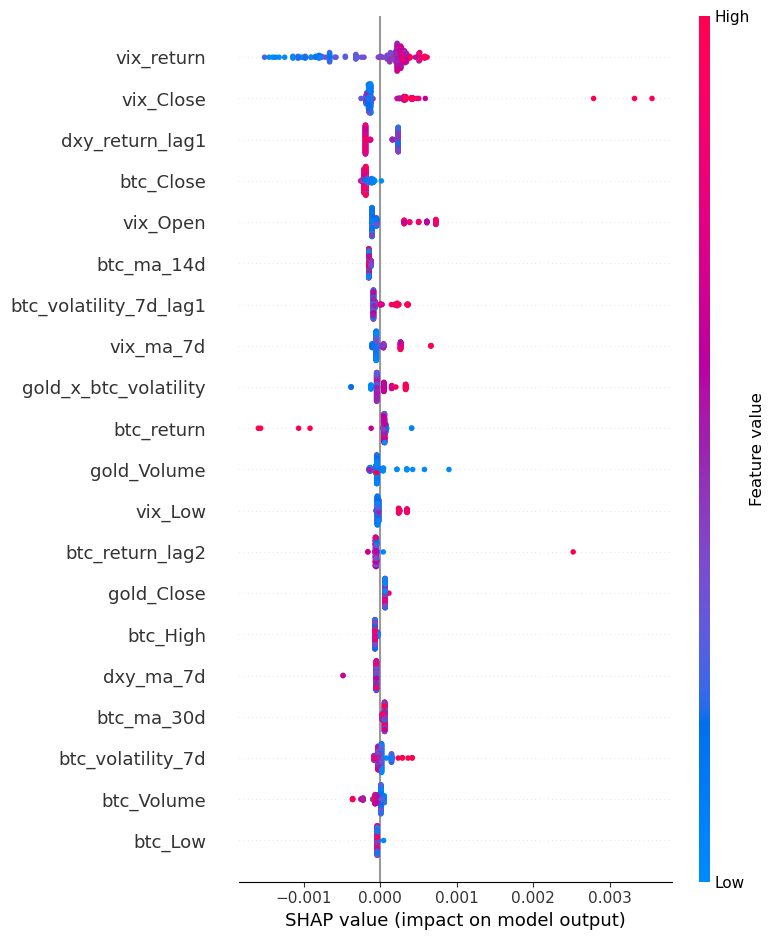

In [57]:
shap.summary_plot(
    shap_values,
    X_test
)

### 7.2.5. Interpretación del Summary Plot

El análisis SHAP mostró que las contribuciones individuales de las variables se encuentran distribuidas entre múltiples features, sin observarse una variable dominante capaz de explicar por sí sola el comportamiento futuro de BTC.

Las variables asociadas al VIX, al índice DXY y a determinadas características propias de BTC presentaron las contribuciones más relevantes dentro del modelo, mientras que las variables relacionadas con el oro mostraron una influencia más moderada que la sugerida inicialmente por las métricas tradicionales de importancia.

Asimismo, la mayoría de las contribuciones observadas se concentraron alrededor de cero, lo que sugiere que la señal contenida en las variables es relativamente débil y se encuentra dispersa entre distintas fuentes de información.

Estos resultados son consistentes con las métricas obtenidas durante el entrenamiento y refuerzan la hipótesis de que el comportamiento futuro de BTC responde a múltiples factores, ninguno de los cuales parece ejercer una influencia predominante dentro del horizonte temporal analizado.

### 7.2.6. Conclusiones

El análisis mediante SHAP permitió profundizar la interpretación del modelo XGBoost optimizado y complementar las medidas tradicionales de importancia de variables.

Los resultados obtenidos mostraron que las contribuciones de las features se encuentran distribuidas entre múltiples variables y que ninguna de ellas presenta una influencia claramente dominante sobre las predicciones.

En conjunto, las explicaciones obtenidas son coherentes con las métricas de desempeño observadas durante el proyecto y sugieren que la señal disponible se encuentra dispersa entre diversas fuentes de información y parcialmente enmascarada por el elevado nivel de ruido característico de los retornos diarios de BTC.

Más allá del desempeño predictivo alcanzado, el análisis SHAP aporta información valiosa para futuras expansiones del proyecto, permitiendo identificar variables potencialmente relevantes y orientar nuevas hipótesis de investigación.

# 8. Conclusiones generales

## 8.1. Formulación del problema

El objetivo de este proyecto consistió en evaluar si un conjunto de variables construidas a partir de información multiactivo era capaz de aportar señal suficiente para anticipar el retorno diario futuro de BTC.

Para ello se trabajó con datos de Bitcoin, DXY, oro y VIX correspondientes a un horizonte temporal de aproximadamente tres años, desarrollando un pipeline completo de Machine Learning que incluyó adquisición de datos, ingeniería de atributos, entrenamiento de modelos, optimización de hiperparámetros y análisis de interpretabilidad.

## 8.2. Resultados obtenidos

Los modelos evaluados mostraron la existencia de una señal estadística débil dentro del conjunto de datos analizado.

La Regresión Lineal presentó los resultados más robustos, mientras que los modelos más complejos, como Random Forest y XGBoost, no lograron traducir su mayor capacidad de representación en mejoras consistentes sobre las métricas de evaluación.

La optimización de hiperparámetros permitió recuperar parte del desempeño perdido en los modelos no lineales, aunque sin superar los resultados obtenidos por las regresiones.

## 8.3. Hallazgos principales

El proyecto permitió identificar varios hallazgos relevantes:

- La señal contenida en los retornos diarios de BTC parece ser débil y estar distribuida entre múltiples variables.

- La incorporación de modelos más complejos no garantizó una mejora del desempeño predictivo.

- Las explicaciones obtenidas mediante SHAP sugieren que no existe una variable claramente dominante capaz de explicar por sí sola el comportamiento futuro de BTC.

- Variables asociadas al VIX, al índice DXY y a determinadas características propias de BTC mostraron contribuciones relevantes dentro del modelo.

- Las relaciones observadas parecen responder a un ecosistema de múltiples factores más que a una única fuente de información predominante.

## 8.4. Limitaciones del estudio

Los resultados obtenidos deben interpretarse dentro del contexto y alcance definidos para este proyecto.

En primer lugar, el horizonte temporal analizado se limita a aproximadamente tres años de observaciones diarias. Si bien este período permite capturar distintos eventos relevantes del mercado, podría no ser suficiente para representar ciclos completos de comportamiento de los activos estudiados.

Asimismo, el análisis se concentró en un conjunto acotado de variables macro-financieras compuesto por Bitcoin, DXY, Oro y VIX. Existen numerosos factores adicionales —económicos, financieros, regulatorios y geopolíticos— que podrían influir sobre el comportamiento de BTC y que no fueron incorporados en el presente estudio.

Otra limitación relevante está asociada a la frecuencia temporal utilizada. El análisis se realizó sobre datos diarios, por lo que determinadas relaciones estructurales podrían manifestarse con mayor claridad en horizontes semanales, mensuales o de más largo plazo.

Finalmente, los resultados obtenidos reflejan exclusivamente el comportamiento observado durante el período analizado y no deben interpretarse como evidencia definitiva sobre la existencia o inexistencia de relaciones causales entre los activos considerados.

## 8.5. Evaluación de las hipótesis

A continuación se evalúan las hipótesis planteadas al inicio del proyecto a la luz de la evidencia obtenida durante las distintas etapas de análisis, modelado e interpretación.

### H-1: Existe una relación inversa entre la fortaleza del dólar (DXY) y el retorno de Bitcoin.

**Estado:** Evidencia parcial.

Durante el análisis exploratorio y las etapas de modelado se observaron indicios de relación entre variables asociadas al índice DXY y el comportamiento de BTC. Asimismo, distintas variables vinculadas al dólar aparecieron de manera recurrente tanto en los análisis de importancia de variables como en las explicaciones obtenidas mediante SHAP.

Sin embargo, las contribuciones observadas fueron relativamente pequeñas y no permitieron identificar una relación inversa fuerte, estable y dominante a lo largo de todo el período analizado.

**Conclusión:** Los resultados sugieren la existencia de cierta relación entre ambas variables, aunque la evidencia obtenida no resulta suficiente para confirmar una relación inversa robusta y consistente.

---

### H-2: La relación entre Bitcoin y el dólar varía según el nivel de volatilidad del mercado, mostrando mayor intensidad en períodos de alta volatilidad.

**Estado:** No concluyente.

Con el objetivo de capturar posibles cambios de comportamiento asociados al contexto de mercado, se incorporaron variables de volatilidad, regímenes de mercado e interacciones entre activos. Algunas de estas variables mostraron relevancia dentro de los modelos y análisis de interpretabilidad.

No obstante, el diseño del presente estudio estuvo orientado principalmente a la predicción del retorno futuro de BTC y no a la comparación explícita de relaciones entre activos bajo distintos regímenes de volatilidad.

**Conclusión:** La hipótesis permanece abierta y requiere análisis específicos orientados a comparar el comportamiento de BTC y DXY bajo distintos contextos de mercado.

---

### H-3: Bitcoin reacciona con mayor sensibilidad que el oro ante cambios en las condiciones de mercado vinculadas al dólar y al riesgo global.

**Estado:** No concluyente.

Las variables asociadas tanto a BTC como al oro participaron en los distintos modelos y análisis desarrollados durante el proyecto. Sin embargo, las métricas obtenidas y las herramientas de interpretabilidad utilizadas no permiten medir de forma directa la sensibilidad relativa de ambos activos frente a cambios en el entorno macro-financiero.

La formulación original de esta hipótesis requeriría un diseño metodológico específicamente orientado a comparar elasticidades, respuestas relativas o magnitudes de reacción entre activos.

**Conclusión:** La evidencia disponible no permite validar ni refutar esta hipótesis, por lo que se mantiene como una línea de investigación futura.

---

### H-4: La incorporación de variables macro-financieras (DXY, Oro y VIX) mejora la capacidad predictiva del modelo respecto de un enfoque basado únicamente en el historial de BTC.

**Estado:** No respaldada por la evidencia obtenida.

Las variables macro-financieras fueron incorporadas en la construcción de nuevas features y aparecieron reflejadas tanto en los modelos como en los análisis de interpretabilidad. Sin embargo, la expansión del conjunto de variables y la utilización de modelos más complejos no produjeron mejoras sustanciales en las métricas predictivas.

Las regresiones lineales continuaron obteniendo los mejores resultados globales, mientras que los modelos más sofisticados requirieron optimización para acercarse a dichos desempeños sin llegar a superarlos de manera consistente.

**Conclusión:** Dentro del horizonte temporal y del conjunto de datos analizados, la incorporación de variables macro-financieras no permitió demostrar una mejora significativa de la capacidad predictiva respecto de enfoques más simples.

## 8.6. Líneas futuras de investigación

Los resultados obtenidos durante el proyecto permiten identificar diversas líneas de investigación que podrían ampliar el alcance del análisis y profundizar la comprensión de las relaciones observadas.

### Ampliación del horizonte temporal

Una de las principales limitaciones identificadas corresponde al período analizado, restringido a aproximadamente tres años de observaciones. Futuras investigaciones podrían extender el horizonte temporal a diez años o más con el objetivo de capturar distintos ciclos de mercado, contextos macroeconómicos y eventos relevantes para Bitcoin.

Esta ampliación permitiría evaluar si las relaciones observadas en el presente estudio representan patrones estructurales o si corresponden a características particulares del período analizado.

### Evaluación de distintos regímenes de mercado

Los resultados obtenidos sugieren que determinadas relaciones podrían variar en función del contexto de volatilidad y riesgo financiero.

Futuros trabajos podrían segmentar explícitamente los datos en distintos regímenes de mercado y analizar de manera independiente la relación entre BTC, DXY, Oro y VIX bajo condiciones de baja, media y alta volatilidad.

### Incorporación de nuevas variables macro-financieras

El presente estudio se limitó a un conjunto específico de activos y variables financieras. Una posible extensión consiste en incorporar nuevas fuentes de información macroeconómica y de mercado, tales como tasas de interés, inflación, índices bursátiles, liquidez monetaria o indicadores de actividad económica.

Esto permitiría evaluar si la señal observada se fortalece al ampliar el contexto informativo disponible para los modelos.

### Refinamiento de la selección de variables

Las herramientas de interpretabilidad utilizadas durante el proyecto permitieron identificar diferencias en la relevancia relativa de las variables analizadas.

Futuras investigaciones podrían utilizar estos resultados para simplificar el conjunto de features, eliminar variables con bajo aporte informativo e incorporar nuevas variables derivadas de aquellas que mostraron mayor potencial explicativo.

### Exploración de diferentes frecuencias temporales

El análisis se realizó utilizando datos diarios. Sin embargo, algunas relaciones económicas y financieras podrían manifestarse con mayor claridad en horizontes semanales o mensuales.

La comparación entre distintas frecuencias temporales permitiría evaluar si la señal detectada se fortalece o se debilita al modificar la escala de observación.

### Evaluación de modelos alternativos

Si bien el presente estudio comparó regresiones lineales, Random Forest y XGBoost, futuras extensiones podrían incorporar arquitecturas específicamente diseñadas para series temporales, redes neuronales recurrentes o modelos orientados a capturar dependencias temporales de largo plazo.

### Análisis de robustez adicionales

Futuras investigaciones podrían incorporar análisis de robustez adicionales mediante distintos puntos de corte temporal entre entrenamiento y prueba con el objetivo de evaluar la estabilidad de los resultados obtenidos.

### Reflexión final

Los resultados obtenidos sugieren que la capacidad predictiva del retorno diario de BTC continúa siendo un problema complejo, caracterizado por señales débiles y distribuidas entre múltiples factores.

Más que proporcionar respuestas definitivas, este proyecto permitió delimitar con mayor precisión las preguntas relevantes y establecer una base metodológica sólida para futuras investigaciones sobre la interacción entre Bitcoin y variables macro-financieras.